# MXN441: Assignment 2 Code

**Authors:**  
Jack Fewtrell (n11278331)   
Madeline Miller (n10267646)   

**Selected Paper:**    
*Hybrid ViT-CNN Network for Fine-Grained Image Classification*   

**Description:**  
This notebook contains code developed for Assignment 2 in MXN441, based on the selected paper above.

## Required packages 


In [21]:
import numpy as np
import pandas as pd
import re

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torch.utils.data import Dataset
# VIT  
from torchvision import transforms
from torchvision.models.vision_transformer import VisionTransformer
from torchvision.models import vit_b_16, ViT_B_16_Weights

# Pillow for images 
from PIL import Image

# Test train split 
from sklearn.model_selection import train_test_split

# Progress bar 
from tqdm import tqdm

import torch.nn as nn
from torchvision import models, transforms
from torchvision.models import ResNet50_Weights
from sklearn.preprocessing import LabelEncoder
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
import copy
import time
import torch

# Plots
import matplotlib.pyplot as plt

# Helper functions 
from helpers.HVCNet import HVC
from helpers.dataloader import getImage

from helpers.diagnostics import top5_accuracy

from sklearn.metrics import (
    classification_report,
    accuracy_score,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)


from torch.optim.lr_scheduler import CosineAnnealingLR, LambdaLR


## Importing Data 

The version of the dataset can be found on Kaggle, due to the size of the data set, it cannot be included in the submission. A version can be found through the following link on OneDrive: 

The dataset is imported by following the process below. 

In [13]:
# Accessing the classes 
nclass = 200 # number of classes 
classes = []

# Path to the folder containing the CUB-200-2011 dataset
data_location = "Data/CUB_200_2011/CUB_200_2011/"
#data_location = r"C:\Users\n10267646\Downloads\CUB_200_2011\CUB_200_2011" # *** TO BE REMOVED BEFORE SUBMISSION


with open(f"{data_location}/classes.txt") as f:
  for x in f:
    match = re.search(r"\d+\.[A-Za-z_]+", x)
    if match:
        classes.append(match.group(0))

# Accessing the image names and ID's 
image_ids = []
image_names = []
with open(f"{data_location}/images.txt") as f:
  for x in f:
    match = re.search(r"(\d+)\s+(.+)", x)
    if match:
        image_ids.append(match.group(1))
        image_names.append(match.group(2))

# Getting image class labels 
image_classes = []
with open(f"{data_location}/image_class_labels.txt") as f:
    for x in f: 
        match = re.search(r" (\d+)", x)
        if match:
            temp = (match.group(1))
            image_classes.append(classes[int(temp) - 1])

# import the path to the images 
image_path = []
for x in range(len(image_names)):
    image_path.append(f"{data_location}/images/{image_names[x]}")

# saving images to memory takes time, may open them as needed 
#for x in range(len(image_names)):
#    img = Image.open(f"{data_location}/images/{image_names[x]}") 
#    images.append(img.copy())
#    img.close()

# importing provided training and testing sets 
isTraining = [] 
with open(f"{data_location}/train_test_split.txt") as f:
    for x in f: 
        match = re.search(r"(\d+) (\d+)", x) 
        if match:
            isTraining.append(int(match.group(2)))

# creating a data frame, listing Images and their subsequent locations 
data = {
    "ID": image_ids,
    "Name": image_names,
    "Class": image_classes,
    "Image Path": image_path,
    "isTraining": isTraining
}

df = pd.DataFrame(data)


In [14]:
# Creating map of classes 
classes_unique = sorted(df["Class"].unique())
label_map = {c: i for i, c in enumerate(classes_unique)}

## Data Preprocessing 

The CUB dataset provides coordinates specifying the location of each bird within an image. The code below loads these coordinates and stores the associated boundary box information.

In [15]:
# Initialise dictionary to store bounding box coordinates for each image
bbox_dict = {}

with open(f"{data_location}/bounding_boxes.txt") as f:
    for line in f:
        # Split each line into image ID and boundary box values
        parts = line.strip().split()
        # Extract image ID
        img_id = int(parts[0])  
        # Extract boundary box coordinates
        x, y, w, h = map(float, parts[1:]) # (x,y) = position of top-left corner, (w,h) = width and height of boundary box in pixels
        # Store bounding box information using image ID as the key
        bbox_dict[img_id] = (x, y, w, h)   

## Data Split 

**TO CHANGE**
The data set provided has it's own suggested training and test split. Therefore, this split will be kept. An additional validation set will be split from the training set for training purposes. This will be 30% of the training set. 

In [16]:
# Set seed for reproducibility
seed = 10

# First split: 70% train, 30% temp
train_df, temp_df = train_test_split(
    df, 
    test_size=0.30, 
    stratify=df["Class"], 
    random_state=seed
)

# Second split: split 30% temp into 15% val and 15% test
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["Class"],
    random_state=seed
)

# Extract IDs
trainID = train_df["ID"]
valID = val_df["ID"]
testID = test_df["ID"]

## Paper Method Replication

**HVCNet Model**

Following the architecture in figure 1 of the paper, we can develop the following model. 

In [57]:
class CUBDataset(Dataset):

    def __init__(self, df, transform=None, size=224):
        """
        Initialise dataset.

        Input:
        df (pd.DataFrame): dataframe containing image information.
        transform: torchvision transform pipeline.
        size (int): output image size.
        """
        # --- Store inside class: ---
        self.df = df.reset_index(drop=True) # dataframe
        self.transform = transform          # transform pipeline
        self.size = size                    # output image size (used in getImage)

    def __len__(self):
        """
        Returns number of images in dataset.
        """
        return len(self.df)

    def __getitem__(self, idx):
        """
        Loads and preprocesses a single image.

        Input:
        idx (int): image index.

        Output:
        image: processed image tensor.
        label: integer class label.
        """

        # Get df row corresponding to image index
        row = self.df.iloc[idx]

        # --- Load and preprocess image ---
        # (convert to RGB, crop to bounding box + padding, resize)
        image = getImage(
            path=row["Image Path"],
            size=self.size,
            img_ID=int(row["ID"]),
            bbox_dict=bbox_dict
        )

        # Apply transform pipeline (if transform is specified)
        if self.transform:
            image = self.transform(image)

        # Get class label (integer)
        label = label_map[row["Class"]]
        label = torch.tensor(label, dtype=torch.long)

        # Return image and label as a tuple
        return image, label

In [62]:
# ------------- Transforms -------------
train_transform_vit = transforms.Compose([

    # Random crop + scale augmentation
    transforms.RandomResizedCrop(
        224,
        scale=(0.8, 1.0)
    ),

    # Random horizontal flip
    transforms.RandomHorizontalFlip(p=0.5),

    # Colour augmentation
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.05
    ),

    # Convert to tensor
    transforms.ToTensor(),

    # ImageNet normalization
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),

    transforms.RandomErasing(
        p=0.25,
        scale=(0.02, 0.1)
    )
])


test_transform_vit = transforms.Compose([

    transforms.Resize((224, 224)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# ------------- Datasets-------------
train_dataset_vit = CUBDataset(
    train_df,
    transform=train_transform_vit
)

val_dataset_vit = CUBDataset(
    val_df,
    transform=test_transform_vit
)

test_dataset_vit = CUBDataset(
    test_df,
    transform=test_transform_vit
)


# ------------- Data loaders -------------

train_loader_vit = DataLoader(
    train_dataset_vit,
    batch_size=16,
    shuffle=True,
 #   num_workers=0,
    pin_memory=True
)

val_loader_vit = DataLoader(
    val_dataset_vit,
    batch_size=16,
    shuffle=False,
#    num_workers=0,
    pin_memory=True
)

test_loader_vit = DataLoader(
    test_dataset_vit,
    batch_size=16,
    shuffle=False,
#    num_workers=0,
    pin_memory=True
)

In [18]:

model = HVC(
    dim=384,
    depth=4,
    heads=8,
    num_classes=nclass,
    M = 10
)


**Defining Model**

In [19]:
B = 16 # the batch size 
N = 196
C = 384


model = HVC(
    dim=384,
    depth=4,
    heads=8,
    num_classes=nclass,
    M = 10
)

**Training Model**

In [17]:

# Maximum number of training epochs
num_epochs = 20



# --- device ---
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)


criterion = nn.CrossEntropyLoss(
    label_smoothing=0.1
)

# initialise model
HVC_model = HVC(
    dim=384,
    depth=10,
    heads=8,
    num_classes=nclass,
    M=10
).to(device)

#optimizer = torch.optim.Adam(
 #   HVC_model.parameters(),
  #  lr=0.02,
   # weight_decay=0.05
#)

##################################################################################
optimizer = torch.optim.AdamW(
    HVC_model.parameters(),
    lr=1e-3,
    weight_decay=0.05
)
# Warmup scheduler
warmup_epochs = 5

def warmup_lambda(epoch):
    return (epoch + 1) / warmup_epochs

warmup_scheduler = LambdaLR(
    optimizer,
    lr_lambda=warmup_lambda
)

cosine_scheduler = CosineAnnealingLR(
    optimizer,
    T_max=num_epochs
)
# Or simpler: just start with lower LR
#optimizer = torch.optim.Adam(
#    HVC_model.parameters(),
#    lr=0.0001,  # ✅ Start much lower
#    weight_decay=0.05
#)



##################################################################################

# Learning rate scheduler
#scheduler = ReduceLROnPlateau(
 #   optimizer,
  #  mode="max",
   # factor=0.5,
 #   patience=3
#)

# ---- Training settings
num_epochs = 25

best_acc = 0.0

patience = 6
epochs_no_improve = 0

# Store losses/accuracies
train_losses_H = []
val_losses_H = []

train_accuracies_H = []
val_accuracies_H = []



####################################
for epoch in range(num_epochs):

    # ---------------- TRAINING ----------------

    HVC_model.train()

    train_loss = 0.0
    correct = 0
    total = 0

    train_loop = tqdm(
        train_loader_vit,
        desc=f"Epoch {epoch+1}/{num_epochs}"
    )

    for imgs, labels in train_loop:

        imgs = imgs.to(device)
        labels = labels.to(device)

        # Forward pass
        outputs = HVC_model(imgs)

        # Compute loss
        loss = criterion(outputs, labels)

        # Backpropagation
        optimizer.zero_grad()

        loss.backward()

        # Check gradients
        for name, param in HVC_model.named_parameters():
            if param.grad is not None:
                grad_norm = param.grad.norm().item()
                if grad_norm == 0 or torch.isnan(param.grad).any():
                    print(f"⚠️ Problem with {name}: grad_norm = {grad_norm}")

        # ✅ ADD: Gradient clipping for safety
        torch.nn.utils.clip_grad_norm_(HVC_model.parameters(), max_norm=1.0)
    
        optimizer.step()

        # ✅ FIXED: Update training loss correctly
        train_loss += loss.item() * imgs.size(0)  # This part is correct

        # Predictions
        _, preds = torch.max(outputs, 1)

        # Accuracy
        correct += (preds == labels).sum().item()
        total += labels.size(0)

        train_loop.set_postfix(
            loss=loss.item(),
            acc=correct / total
        )

    # Average train loss/accuracy
    # ✅ FIXED: Average train loss correctly
    train_loss = train_loss / total  # Divide by total samples processed
    train_acc = correct / total


    train_losses_H.append(train_loss)
    train_accuracies_H.append(train_acc)

    # ---------------- VALIDATION ----------------

    HVC_model.eval()

    val_loss = 0.0
    correct = 0
    total = 0

    val_loop = tqdm(
        val_loader_vit,
        desc=f"Epoch {epoch+1}/{num_epochs} [Val]"
    )

    with torch.no_grad():

        for imgs, labels in val_loop:

            imgs = imgs.to(device)
            labels = labels.to(device)

            # Forward pass
            outputs = HVC_model(imgs)

            # Validation loss
            loss = criterion(outputs, labels)

            val_loss += loss.item() * imgs.size(0)

            # Predictions
            _, preds = torch.max(outputs, 1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

            val_loop.set_postfix(
                loss=loss.item(),
                acc=correct / total
            )

    # Average validation loss/accuracy
    val_loss = val_loss / total
    val_acc = correct / total

    val_losses_H.append(val_loss)
    val_accuracies_H.append(val_acc)

    # Update LR scheduler
    #scheduler.step(val_acc)

    # Current LR
    current_lr = optimizer.param_groups[0]["lr"]

    print(
        f"Epoch {epoch+1}: "
        f"lr = {current_lr:.6f}, "
        f"train loss = {train_loss:.4f}, "
        f"train acc = {train_acc:.4f}, "
        f"val loss = {val_loss:.4f}, "
        f"val acc = {val_acc:.4f}"
    )

    # Update LR for NEXT epoch
    cosine_scheduler.step()
    # ---------------- SAVE BEST MODEL ----------------

    if val_acc > best_acc:

        best_acc = val_acc

        torch.save(
            HVC_model.state_dict(),
            "best_model2_HVCNet.pth"
        )

        epochs_no_improve = 0

    else:

        epochs_no_improve += 1

        print(
            f"No improvement for "
            f"{epochs_no_improve} epoch(s)"
        )

    # ---------------- EARLY STOPPING ----------------

    if epochs_no_improve >= patience:

        print("Early stopping triggered")

        break

# --- best model
HVC_model.load_state_dict(
    torch.load("best_model2_HVCNet.pth")
)

print("Training complete")

Output: torch.Size([16, 200])


# ADDED CODE - RUN THIS

In [ ]:
# ------------- Transforms -------------
train_transform_vit = transforms.Compose([

    # Random crop + scale augmentation
    transforms.RandomResizedCrop(
        224,
        scale=(0.8, 1.0)
    ),

    # Random horizontal flip
    transforms.RandomHorizontalFlip(p=0.5),

    # Colour augmentation
    transforms.ColorJitter(
        brightness=0.1,
        contrast=0.1,
        saturation=0.1
    ),

    # Convert to tensor
    transforms.ToTensor(),

    # ImageNet normalization
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


test_transform_vit = transforms.Compose([

    transforms.Resize((224, 224)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# ------------- Datasets-------------
train_dataset_vit = CUBDataset(
    train_df,
    transform=train_transform_vit
)

val_dataset_vit = CUBDataset(
    val_df,
    transform=test_transform_vit
)

test_dataset_vit = CUBDataset(
    test_df,
    transform=test_transform_vit
)


# ------------- Data loaders -------------

train_loader_vit = DataLoader(
    train_dataset_vit,
    batch_size=16,
    shuffle=True,
 #   num_workers=0,
    pin_memory=True
)

val_loader_vit = DataLoader(
    val_dataset_vit,
    batch_size=16,
    shuffle=False,
#    num_workers=0,
    pin_memory=True
)

test_loader_vit = DataLoader(
    test_dataset_vit,
    batch_size=16,
    shuffle=False,
#    num_workers=0,
    pin_memory=True
)

# --- device ---
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)
model = model.to(device)


criterion = nn.CrossEntropyLoss(
    label_smoothing=0.1
)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-3
)

# Learning rate scheduler
scheduler = ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=2
)

# ---- Training settings
num_epochs = 25

best_acc = 0.0

patience = 5
epochs_no_improve = 0

# Store losses/accuracies
train_losses_H = []
val_losses_H = []

train_accuracies_H = []
val_accuracies_H = []

####################################
for epoch in range(num_epochs):

    # ---------------- TRAINING ----------------

    model.train()

    train_loss = 0.0
    correct = 0
    total = 0

    train_loop = tqdm(
        train_loader_vit,
        desc=f"Epoch {epoch+1}/{num_epochs}"
    )

    for imgs, labels in train_loop:

        imgs = imgs.to(device)
        labels = labels.to(device)

        # Forward pass
        outputs = model(imgs)

        # Compute loss
        loss = criterion(outputs, labels)

        # Backpropagation
        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        # Update training loss
        train_loss += loss.item() * imgs.size(0)

        # Predictions
        _, preds = torch.max(outputs, 1)

        # Accuracy
        correct += (preds == labels).sum().item()
        total += labels.size(0)

        train_loop.set_postfix(
            loss=loss.item(),
            acc=correct / total
        )

    # Average train loss/accuracy
    train_loss /= len(train_dataset_vit)
    train_acc = correct / total

    train_losses_H.append(train_loss)
    train_accuracies_H.append(train_acc)

    # ---------------- VALIDATION ----------------

    model.eval()

    val_loss = 0.0
    correct = 0
    total = 0

    val_loop = tqdm(
        val_loader_vit,
        desc=f"Epoch {epoch+1}/{num_epochs} [Val]"
    )

    with torch.no_grad():

        for imgs, labels in val_loop:

            imgs = imgs.to(device)
            labels = labels.to(device)

            # Forward pass
            outputs = model(imgs)

            # Validation loss
            loss = criterion(outputs, labels)

            val_loss += loss.item() * imgs.size(0)

            # Predictions
            _, preds = torch.max(outputs, 1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

            val_loop.set_postfix(
                loss=loss.item(),
                acc=correct / total
            )

    # Average validation loss/accuracy
    val_loss /= len(val_dataset_vit)
    val_acc = correct / total

    val_losses_H.append(val_loss)
    val_accuracies_H.append(val_acc)

    # Update LR scheduler
    scheduler.step(val_acc)

    # Current LR
    current_lr = optimizer.param_groups[0]["lr"]

    print(
        f"Epoch {epoch+1}: "
        f"lr = {current_lr:.6f}, "
        f"train loss = {train_loss:.4f}, "
        f"train acc = {train_acc:.4f}, "
        f"val loss = {val_loss:.4f}, "
        f"val acc = {val_acc:.4f}"
    )

    # ---------------- SAVE BEST MODEL ----------------

    if val_acc > best_acc:

        best_acc = val_acc

        torch.save(
            model.state_dict(),
            "best_model_hybrid.pth"
        )

        epochs_no_improve = 0

    else:

        epochs_no_improve += 1

        print(
            f"No improvement for "
            f"{epochs_no_improve} epoch(s)"
        )

    # ---------------- EARLY STOPPING ----------------

    if epochs_no_improve >= patience:

        print("Early stopping triggered")

        break

# --- best model
model.load_state_dict(
    torch.load("best_model_hybrid.pth")
)

print("Training complete")

In [ ]:
#--- Plot training and validation loss vs. epoch ---

plt.figure(figsize=(8, 5))

plt.plot(train_losses_H, label="Training Loss")
plt.plot(val_losses_H, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")

plt.legend()
plt.grid(True)

plt.show()

# --- Plot training and validation accuracy vs. epoch ---

plt.figure(figsize=(8, 5))

plt.plot(train_accuracies, label="Training Accuracy")
plt.plot(val_accuracies, label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")

plt.legend()
plt.grid(True)

plt.show()

In [29]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4)

best_acc = 0
patience = 5

for epoch in range(5):
    model.train()

    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/5")

    for imgs, labels in loop:
        imgs, labels = imgs.to(device), labels.to(device)

        logits = model(imgs)
        loss = criterion(logits, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        loop.set_postfix(loss=loss.item())

    # Validation 
    model.eval()
    correct = 0
    total = 0
    val_loop = tqdm(val_loader, desc=f"Epoch {epoch+1}/5 [Val]")
    with torch.no_grad():
        for imgs, labels in val_loop:
            imgs, labels = imgs.to(device), labels.to(device)

            outputs = model(imgs)
            _, preds = torch.max(outputs, 1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

            val_loop.set_postfix(
                loss=loss.item(),
                acc=correct / total
            )

    val_acc = correct / total

    print(f"Epoch {epoch+1}, Val Acc: {val_acc:.4f}")

    if val_acc > best_acc:

        best_acc = val_acc
        torch.save(model.state_dict(), "best_model.pth")

Epoch 1/5 [Val]: 100%|██████████████████████████████████████████| 56/56 [00:09<00:00,  5.83it/s, acc=0.0373, loss=5.09]


Epoch 1, Val Acc: 0.0373


Epoch 2/5 [Val]: 100%|██████████████████████████████████████████| 56/56 [00:09<00:00,  5.81it/s, acc=0.0933, loss=4.51]


Epoch 2, Val Acc: 0.0933


Epoch 3/5 [Val]: 100%|████████████████████████████████████████████| 56/56 [00:09<00:00,  6.11it/s, acc=0.201, loss=3.6]


Epoch 3, Val Acc: 0.2008


Epoch 4/5 [Val]: 100%|███████████████████████████████████████████| 56/56 [00:09<00:00,  6.09it/s, acc=0.297, loss=2.78]


Epoch 4, Val Acc: 0.2969


Epoch 5/5 [Val]: 100%|███████████████████████████████████████████| 56/56 [00:09<00:00,  6.01it/s, acc=0.376, loss=1.81]

**Testing Model**

In [30]:
# --- TEST SET EVALUATION ---

# Set model to evaluation mode
model.eval()

# Track metrics
correct_top1 = 0
correct_top5 = 0
total = 0
test_loss = 0

# Store predictions and true labels
preds_HVC = []
true_HVC = []

# Store Top-5 predictions
top5_HVC = []

criterion = torch.nn.CrossEntropyLoss()

# Progress bar
test_loop = tqdm(test_loader, desc="Testing")

# Disable gradient computation
with torch.no_grad():

    for imgs, labels in test_loop:

        # Move batch to GPU/CPU
        imgs = imgs.to(device)
        labels = labels.to(device)

        # Forward pass
        outputs = model(imgs)

        # Compute loss
        loss = criterion(outputs, labels)

        # Update loss
        test_loss += loss.item()

        # Top-1 predictions
        _, preds = torch.max(outputs, 1)

        # Top-5 predictions
        _, top5_preds = torch.topk(outputs, 5, dim=1)

        # Store predictions and labels
        preds_HVC.extend(preds.cpu().numpy())
        true_HVC.extend(labels.cpu().numpy())

        # Store Top-5 predictions
        top5_HVC.extend(top5_preds.cpu().numpy())

        # Update Top-1 accuracy
        correct_top1 += (preds == labels).sum().item()

        # Update Top-5 accuracy
        correct_top5 += (
            top5_preds == labels.view(-1, 1)
        ).sum().item()

        # Update total samples
        total += labels.size(0)

# Final accuracies
top1_acc_HVC = correct_top1 / total
top5_acc_HVC = correct_top5 / total

print(f"Test Loss: {test_loss/len(test_loader):.4f}")
print(f"Top-1 Accuracy: {top1_acc_HVC*100:.2f}%")
print(f"Top-5 Accuracy: {top5_acc_HVC*100:.2f}%")

Testing: 100%|█████████████████████████████████████████████████████████████████████████| 56/56 [00:09<00:00,  5.95it/s]

Test Loss: 2.6905
Test Accuracy: 34.60%


### HVCNet w/pretrained 

In [25]:

# --- device ---
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

# --- Baseline ViT-B/16 ---
weights      = ViT_B_16_Weights.DEFAULT
vit_baseline = vit_b_16(weights=weights)

# Replace head for your dataset
in_features  = vit_baseline.heads.head.in_features   # 768
vit_baseline.heads.head = nn.Linear(in_features, nclass)
vit_baseline = vit_baseline.to(device)

hvc_model =  HVC(
    dim=768,
    depth=10,
    heads=12,
    num_classes=nclass,
    M = 10
)

vit_loader = vit_b_16(weights=ViT_B_16_Weights.DEFAULT)

for i in range(len(hvc_model.feature_layers)):
    block = vit_loader.encoder.layers[i]

    # Attention weights — torchvision uses different key names to timm
    hvc_model.feature_layers[i].msa.attn.in_proj_weight.data.copy_(
        block.self_attention.in_proj_weight
    )
    hvc_model.feature_layers[i].msa.attn.in_proj_bias.data.copy_(
        block.self_attention.in_proj_bias
    )
    hvc_model.feature_layers[i].msa.attn.out_proj.weight.data.copy_(
        block.self_attention.out_proj.weight
    )
    hvc_model.feature_layers[i].msa.attn.out_proj.bias.data.copy_(
        block.self_attention.out_proj.bias
    )

    # LayerNorm weights
    hvc_model.feature_layers[i].norm1.weight.data.copy_(block.ln_1.weight)
    hvc_model.feature_layers[i].norm1.bias.data.copy_(block.ln_1.bias)
    hvc_model.feature_layers[i].norm2.weight.data.copy_(block.ln_2.weight)
    hvc_model.feature_layers[i].norm2.bias.data.copy_(block.ln_2.bias)

del vit_loader
torch.cuda.empty_cache()
print("ViT-B/16 weights loaded into HVC successfully")




# Maximum number of training epochs
num_epochs = 20





criterion = nn.CrossEntropyLoss(
    label_smoothing=0.1
)

# initialise model
hvc_model.to(device)

#optimizer = torch.optim.Adam(
 #   HVC_model.parameters(),
  #  lr=0.02,
   # weight_decay=0.05
#)

##################################################################################
optimizer = torch.optim.AdamW(
    hvc_model.parameters(),
    lr=1e-3,
    weight_decay=0.05
)
# Warmup scheduler
warmup_epochs = 5

def warmup_lambda(epoch):
    return (epoch + 1) / warmup_epochs

warmup_scheduler = LambdaLR(
    optimizer,
    lr_lambda=warmup_lambda
)

cosine_scheduler = CosineAnnealingLR(
    optimizer,
    T_max=num_epochs
)
# Or simpler: just start with lower LR
#optimizer = torch.optim.Adam(
#    HVC_model.parameters(),
#    lr=0.0001,  # ✅ Start much lower
#    weight_decay=0.05
#)



##################################################################################

# Learning rate scheduler
#scheduler = ReduceLROnPlateau(
 #   optimizer,
  #  mode="max",
   # factor=0.5,
 #   patience=3
#)

# ---- Training settings
num_epochs = 25

best_acc = 0.0

patience = 6
epochs_no_improve = 0

# Store losses/accuracies
train_losses_H = []
val_losses_H = []

train_accuracies_H = []
val_accuracies_H = []



####################################
for epoch in range(num_epochs):

    # ---------------- TRAINING ----------------

    hvc_model.train()

    train_loss = 0.0
    correct = 0
    total = 0

    train_loop = tqdm(
        train_loader_vit,
        desc=f"Epoch {epoch+1}/{num_epochs}"
    )

    for imgs, labels in train_loop:

        imgs = imgs.to(device)
        labels = labels.to(device)

        # Forward pass
        outputs = hvc_model(imgs)

        # Compute loss
        loss = criterion(outputs, labels)

        # Backpropagation
        optimizer.zero_grad()

        loss.backward()

        # Check gradients
        for name, param in hvc_model.named_parameters():
            if param.grad is not None:
                grad_norm = param.grad.norm().item()
                if grad_norm == 0 or torch.isnan(param.grad).any():
                    print(f"⚠️ Problem with {name}: grad_norm = {grad_norm}")

        # ✅ ADD: Gradient clipping for safety
        torch.nn.utils.clip_grad_norm_(hvc_model.parameters(), max_norm=1.0)
    
        optimizer.step()

        # ✅ FIXED: Update training loss correctly
        train_loss += loss.item() * imgs.size(0)  # This part is correct

        # Predictions
        _, preds = torch.max(outputs, 1)

        # Accuracy
        correct += (preds == labels).sum().item()
        total += labels.size(0)

        train_loop.set_postfix(
            loss=loss.item(),
            acc=correct / total
        )

    # Average train loss/accuracy
    # ✅ FIXED: Average train loss correctly
    train_loss = train_loss / total  # Divide by total samples processed
    train_acc = correct / total


    train_losses_H.append(train_loss)
    train_accuracies_H.append(train_acc)

    # ---------------- VALIDATION ----------------

    hvc_model.eval()

    val_loss = 0.0
    correct = 0
    total = 0

    val_loop = tqdm(
        val_loader_vit,
        desc=f"Epoch {epoch+1}/{num_epochs} [Val]"
    )

    with torch.no_grad():

        for imgs, labels in val_loop:

            imgs = imgs.to(device)
            labels = labels.to(device)

            # Forward pass
            outputs = hvc_model(imgs)

            # Validation loss
            loss = criterion(outputs, labels)

            val_loss += loss.item() * imgs.size(0)

            # Predictions
            _, preds = torch.max(outputs, 1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

            val_loop.set_postfix(
                loss=loss.item(),
                acc=correct / total
            )

    # Average validation loss/accuracy
    val_loss = val_loss / total
    val_acc = correct / total

    val_losses_H.append(val_loss)
    val_accuracies_H.append(val_acc)

    # Update LR scheduler
    #scheduler.step(val_acc)

    # Current LR
    current_lr = optimizer.param_groups[0]["lr"]

    print(
        f"Epoch {epoch+1}: "
        f"lr = {current_lr:.6f}, "
        f"train loss = {train_loss:.4f}, "
        f"train acc = {train_acc:.4f}, "
        f"val loss = {val_loss:.4f}, "
        f"val acc = {val_acc:.4f}"
    )

    # Update LR for NEXT epoch
    cosine_scheduler.step()
    # ---------------- SAVE BEST MODEL ----------------

    if val_acc > best_acc:

        best_acc = val_acc

        torch.save(
            hvc_model.state_dict(),
            "best_model2_HVCNet.pth"
        )

        epochs_no_improve = 0

    else:

        epochs_no_improve += 1

        print(
            f"No improvement for "
            f"{epochs_no_improve} epoch(s)"
        )

    # ---------------- EARLY STOPPING ----------------

    if epochs_no_improve >= patience:

        print("Early stopping triggered")

        break

# --- best model
hvc_model.load_state_dict(
    torch.load("best_model2_HVCNet_pretrained.pth")
)

print("Training complete")




ViT-B/16 weights loaded into HVC successfully


Epoch 1/25 [Val]: 100%|███████████████████████████████████████| 111/111 [00:10<00:00, 10.20it/s, acc=0.0701, loss=3.96]


Epoch 1: lr = 0.000200, train loss = 5.0200, train acc = 0.0356, val loss = 4.5261, val acc = 0.0701


Epoch 2/25 [Val]: 100%|█████████████████████████████████████████| 111/111 [00:12<00:00,  9.13it/s, acc=0.265, loss=2.5]


Epoch 2: lr = 0.000199, train loss = 3.9676, train acc = 0.1577, val loss = 3.4412, val acc = 0.2653


...

Epoch 24/25 [Val]: 100%|███████████████████████████████████████| 111/111 [00:11<00:00,  9.37it/s, acc=0.671, loss=1.68]


Epoch 24: lr = 0.000054, train loss = 1.0286, train acc = 0.9926, val loss = 2.1444, val acc = 0.6708
No improvement for 2 epoch(s)


Epoch 25/25 [Val]: 100%|███████████████████████████████████████| 111/111 [00:11<00:00,  9.43it/s, acc=0.635, loss=1.78]
C:\Users\Jack\AppData\Local\Temp\ipykernel_27220\3054719703.py:295: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on G

Epoch 25: lr = 0.000095, train loss = 1.0720, train acc = 0.9858, val loss = 2.2524, val acc = 0.6352
No improvement for 3 epoch(s)


FileNotFoundError: [Errno 2] No such file or directory: 'best_model2_HVCNet_pretrained.pth'

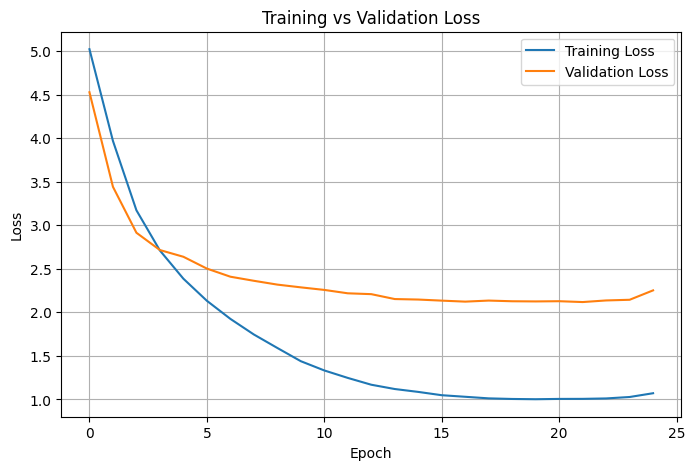

In [29]:
plt.figure(figsize=(8, 5))

plt.plot(train_losses_H, label="Training Loss")
plt.plot(val_losses_H, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")

plt.legend()
plt.grid(True)

plt.show()

In [28]:
# Helper functions 


hvc_model.load_state_dict(
    torch.load("best_model2_HVCNet.pth")
)

hvc_model.eval()

# Track metrics
correct_top1 = 0
correct_top5 = 0
total = 0
test_loss = 0

# Store predictions and true labels
preds_ViT = []
true_ViT = []

# Store Top-5 predictions
top5_ViT = []

criterion = torch.nn.CrossEntropyLoss()

# Progress bar
test_loop = tqdm(test_loader_vit, desc="Testing")

# Disable gradient computation
with torch.no_grad():

    for imgs, labels in test_loop:

        # Move batch to GPU/CPU
        imgs = imgs.to(device)
        labels = labels.to(device)

        # Forward pass
        outputs = hvc_model(imgs)

        # Compute loss
        loss = criterion(outputs, labels)

        # Update loss
        test_loss += loss.item()

        # Top-1 predictions
        _, preds = torch.max(outputs, 1)

        # Top-5 predictions
        _, top5_preds = torch.topk(outputs, 5, dim=1)

        # Store predictions and labels
        preds_ViT.extend(preds.cpu().numpy())
        true_ViT.extend(labels.cpu().numpy())

        # Store Top-5 predictions
        top5_ViT.extend(top5_preds.cpu().numpy())

        # Update Top-1 accuracy
        correct_top1 += (preds == labels).sum().item()

        # Update Top-5 accuracy
        correct_top5 += (
            top5_preds == labels.view(-1, 1)
        ).sum().item()

        # Update total samples
        total += labels.size(0)

# Final accuracies
top1_acc_ViT = correct_top1 / total
top5_acc_ViT = correct_top5 / total

print(f"Test Loss: {test_loss/len(test_loader_vit):.4f}")
print(f"Top-1 Accuracy: {top1_acc_ViT*100:.2f}%")
print(f"Top-5 Accuracy: {top5_acc_ViT*100:.2f}%")

print("\n========== ViT ==========")

print(f"Top-1 Accuracy : {accuracy_score(true_ViT, preds_ViT):.4f}")
print(f"Top-5 Accuracy : {top5_accuracy(true_ViT, top5_ViT):.4f}")
print(f"Precision      : {precision_score(true_ViT, preds_ViT, average='weighted'):.4f}")
print(f"Recall         : {recall_score(true_ViT, preds_ViT, average='weighted'):.4f}")
print(f"F1 Score       : {f1_score(true_ViT, preds_ViT, average='weighted'):.4f}")

print("\nClassification Report:")
print(classification_report(true_ViT, preds_ViT))

C:\Users\Jack\AppData\Local\Temp\ipykernel_27220\2075612729.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load("best_model2_HVCNet.pth")
Testing: 100%|██████████

Test Loss: 1.5727
Top-1 Accuracy: 67.16%
Top-5 Accuracy: 86.55%

========== ViT ==========
Top-1 Accuracy : 0.6716
Top-5 Accuracy : 0.8655
Precision      : 0.6866
Recall         : 0.6716
F1 Score       : 0.6660

Classification Report:
              precision    recall  f1-score   support

           0       0.39      0.78      0.52         9
           1       0.33      0.22      0.27         9
           2       0.67      0.44      0.53         9
           3       0.50      0.67      0.57         9
           4       0.40      0.33      0.36         6
           5       0.67      0.67      0.67         6
           6       0.71      0.62      0.67         8
           7       0.62      0.71      0.67         7
           8       0.57      0.44      0.50         9
           9       0.73      0.89      0.80         9
          10       0.50      0.33      0.40         9
          11       1.00      0.88      0.93         8
          12       0.88      0.78      0.82         9
        

## Implementation 1 - VIT

In [64]:
class CUBDataset(Dataset):

    def __init__(self, df, transform=None, size=224):
        """
        Initialise dataset.

        Input:
        df (pd.DataFrame): dataframe containing image information.
        transform: torchvision transform pipeline.
        size (int): output image size.
        """
        # --- Store inside class: ---
        self.df = df.reset_index(drop=True) # dataframe
        self.transform = transform          # transform pipeline
        self.size = size                    # output image size (used in getImage)

    def __len__(self):
        """
        Returns number of images in dataset.
        """
        return len(self.df)

    def __getitem__(self, idx):
        """
        Loads and preprocesses a single image.

        Input:
        idx (int): image index.

        Output:
        image: processed image tensor.
        label: integer class label.
        """

        # Get df row corresponding to image index
        row = self.df.iloc[idx]

        # --- Load and preprocess image ---
        # (convert to RGB, crop to bounding box + padding, resize)
        image = getImage(
            path=row["Image Path"],
            size=self.size,
            img_ID=int(row["ID"]),
            bbox_dict=bbox_dict
        )

        # Apply transform pipeline (if transform is specified)
        if self.transform:
            image = self.transform(image)

        # Get class label (integer)
        label = label_map[row["Class"]]
        label = torch.tensor(label, dtype=torch.long)

        # Return image and label as a tuple
        return image, label

In [65]:
# --- Transform pipeline for training data ---
train_transform = transforms.Compose([

    # Data augmentation 
    transforms.RandomHorizontalFlip(p=0.5),               # random horizontal flip
    transforms.RandomRotation(degrees=10),                # random rotation
    transforms.ColorJitter(brightness=0.1, saturation=0.1, 
                           contrast=0.1), # random brightness and contrast adjustment

    # Convert image to tensor
    transforms.ToTensor(),

    # Normalize using ImageNet mean and standard deviation
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# --- Transform pipeline for validation/testing ---
test_transform = transforms.Compose([

    # Convert image to tensor
    transforms.ToTensor(),

    # Normalize using ImageNet mean and standard deviation
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Create training, validation and testing dataframes
train_df = df[df["ID"].isin(trainID)]
val_df = df[df["ID"].isin(valID)]
test_df = df[df["ID"].isin(testID)]

# Create training dataset with data augmentation
train_dataset = CUBDataset(
    train_df,
    transform=train_transform
)

# Create validation dataset
val_dataset = CUBDataset(
    val_df,
    transform=test_transform
)

# Create test dataset
test_dataset = CUBDataset(
    test_df,
    transform=test_transform
)

# Create training DataLoader
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=0,
    pin_memory = True
)

# Create validation DataLoader
val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0,
    pin_memory = True
)

# Create test DataLoader
test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0,
    pin_memory = True
)

In [9]:
#

weights = ViT_B_16_Weights.DEFAULT

model = vit_b_16(weights=weights)

model.heads.head = nn.Linear(
    model.heads.head.in_features,
    200
)





In [10]:
print(df.columns)

Index(['ID', 'Name', 'Class', 'Image Path', 'isTraining'], dtype='object')


In [11]:
imgs, labels = next(iter(train_loader))
print(imgs.shape, labels.shape)

torch.Size([32, 3, 224, 224]) torch.Size([32])


In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
print("GPU count:", torch.cuda.device_count())

cuda
GPU count: 1


In [16]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-5, weight_decay = 0.05)

best_acc = 0

for epoch in range(5):
    model.train()

    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/5")

    for imgs, labels in loop:
        imgs, labels = imgs.to(device), labels.to(device)

        logits = model(imgs)
        loss = criterion(logits, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        loop.set_postfix(loss=loss.item())

    # Validation 
    model.eval()
    correct = 0
    total = 0
    val_loop = tqdm(val_loader, desc=f"Epoch {epoch+1}/5 [Val]")
    with torch.no_grad():
        for imgs, labels in val_loop:
            imgs, labels = imgs.to(device), labels.to(device)

            outputs = model(imgs)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    val_acc = correct / total
    print(f"Epoch {epoch+1}, Val Acc: {val_acc:.4f}")

    if val_acc > best_acc:

        best_acc = val_acc
        torch.save(model.state_dict(), "best_model.pth")

Epoch 1/5 [Val]: 100%|███████████████████████████████████████████| 56/56 [00:11<00:00,  4.74it/s, acc=0.156, loss=4.06]


Epoch 1, Val Acc: 0.1555


Epoch 2/5 [Val]: 100%|███████████████████████████████████████████| 56/56 [00:11<00:00,  4.78it/s, acc=0.192, loss=2.91]


Epoch 2, Val Acc: 0.1923


Epoch 3/5 [Val]: 100%|███████████████████████████████████████████| 56/56 [00:11<00:00,  4.71it/s, acc=0.218, loss=3.16]


Epoch 3, Val Acc: 0.2183


Epoch 4/5 [Val]: 100%|███████████████████████████████████████████| 56/56 [00:11<00:00,  4.79it/s, acc=0.239, loss=3.17]


Epoch 4, Val Acc: 0.2387


Epoch 5/5 [Val]: 100%|███████████████████████████████████████████| 56/56 [00:11<00:00,  4.80it/s, acc=0.274, loss=2.47]


Epoch 5, Val Acc: 0.2738


In [17]:
# --- TEST SET EVALUATION ---

# Set model to evaluation mode
ViT.eval()

# Track metrics
correct_top1 = 0
correct_top5 = 0
total = 0
test_loss = 0

# Store predictions and true labels
preds_ViT = []
true_ViT = []

# Store Top-5 predictions
top5_ViT = []

criterion = torch.nn.CrossEntropyLoss()

# Progress bar
test_loop = tqdm(test_loader, desc="Testing")

# Disable gradient computation
with torch.no_grad():

    for imgs, labels in test_loop:

        # Move batch to GPU/CPU
        imgs = imgs.to(device)
        labels = labels.to(device)

        # Forward pass
        outputs = ViT(imgs)

        # Compute loss
        loss = criterion(outputs, labels)

        # Update loss
        test_loss += loss.item()

        # Top-1 predictions
        _, preds = torch.max(outputs, 1)

        # Top-5 predictions
        _, top5_preds = torch.topk(outputs, 5, dim=1)

        # Store predictions and labels
        preds_ViT.extend(preds.cpu().numpy())
        true_ViT.extend(labels.cpu().numpy())

        # Store Top-5 predictions
        top5_ViT.extend(top5_preds.cpu().numpy())

        # Update Top-1 accuracy
        correct_top1 += (preds == labels).sum().item()

        # Update Top-5 accuracy
        correct_top5 += (
            top5_preds == labels.view(-1, 1)
        ).sum().item()

        # Update total samples
        total += labels.size(0)

# Final accuracies
top1_acc_ViT = correct_top1 / total
top5_acc_ViT = correct_top5 / total

print(f"Test Loss: {test_loss/len(test_loader):.4f}")
print(f"Top-1 Accuracy: {top1_acc_ViT*100:.2f}%")
print(f"Top-5 Accuracy: {top5_acc_ViT*100:.2f}%")

Testing: 100%|█████████████████████████████████████████████████████████████████████████| 56/56 [00:14<00:00,  3.82it/s]

Test Loss: 3.1374
Test Accuracy: 25.27%


In [42]:
print("\n========== ViT ==========")

print(f"Top-1 Accuracy : {accuracy_score(true_ViT, preds_ViT):.4f}")
print(f"Top-5 Accuracy : {top5_accuracy(true_ViT, top5_ViT):.4f}")
print(f"Precision      : {precision_score(true_ViT, preds_ViT, average='weighted'):.4f}")
print(f"Recall         : {recall_score(true_ViT, preds_ViT, average='weighted'):.4f}")
print(f"F1 Score       : {f1_score(true_ViT, preds_ViT, average='weighted'):.4f}")

print("\nClassification Report:")
print(classification_report(true_ViT, preds_ViT))


========== ViT ==========


NameError: name 'true_ViT' is not defined

## Implementation 2 - Feature extraction using ResNet50 + XGBoost classifier

The below code loads the pretrained ResNet50 model with ImageNet weights and adapts it for the CUB dataset by replacing the final classification layer with a 200 class output layer. All pretrained layers are frozen, except for the final residual block (layer4) and classification layer which are finetuned. Class labels are also encoded as integer labels.

In [30]:
# Load pretrained ResNet50 model with ImageNet weights
ResNet50 = models.resnet50(weights=ResNet50_Weights.DEFAULT) # default weights are version 2

# Replace final classification layer for 200 classes (CUB)
ResNet50.fc = nn.Linear(ResNet50.fc.in_features, 200)

#### Move model to GPU/CPU
ResNet50.to(device)

# Freeze all pretrained layers
for param in ResNet50.parameters():
    param.requires_grad = False

# Unfreeze final residual block for finetuning 
for param in ResNet50.layer4.parameters():
    param.requires_grad = True

# Unfreeze final classifier layer
for param in ResNet50.fc.parameters():
    param.requires_grad = True

# Encode string class labels as integers (required for model)
label_encoder = LabelEncoder()
df["Label"] = label_encoder.fit_transform(df["Class"])


The training and validation/testing transform pipelines are shown below. Images must undergo the same preprocessing used for pretrained ResNet50 - images are already resized to 224*224 during preprocessing, but still require normalization using the ImageNet mean and standard deviation used by ResNet50. Additionally, data augmentation is used for training images.

In [35]:
# --- Transform pipeline for training data ---
train_transform = transforms.Compose([

    # Data augmentation 
    transforms.RandomHorizontalFlip(p=0.5),               # random horizontal flip
    transforms.RandomRotation(degrees=10),                # random rotation
    transforms.ColorJitter(brightness=0.1, saturation=0.1, 
                           contrast=0.1), # random brightness and contrast adjustment

    # Convert image to tensor
    transforms.ToTensor(),

    # Normalize using ImageNet mean and standard deviation
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# --- Transform pipeline for validation/testing ---
test_transform = transforms.Compose([

    # Convert image to tensor
    transforms.ToTensor(),

    # Normalize using ImageNet mean and standard deviation
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

The code block below defines a custom dataset class for the CUB-200-2011 dataset. For a given image index, the dataset loads the corresponding image, applies preprocessing using the getImage() function (RGB conversion, bounding box cropping with padding, and resizing), applies the transform pipeline, and returns the processed image tensor together with its integer class label.

In [36]:
class CUBDataset(Dataset):

    def __init__(self, df, transform=None, size=224):
        """
        Initialise dataset.

        Input:
        df (pd.DataFrame): dataframe containing image information.
        transform: torchvision transform pipeline.
        size (int): output image size.
        """
        # --- Store inside class: ---
        self.df = df.reset_index(drop=True) # dataframe
        self.transform = transform          # transform pipeline
        self.size = size                    # output image size (used in getImage)

    def __len__(self):
        """
        Returns number of images in dataset.
        """
        return len(self.df)

    def __getitem__(self, idx):
        """
        Loads and preprocesses a single image.

        Input:
        idx (int): image index.

        Output:
        image: processed image tensor.
        label: integer class label.
        """

        # Get df row corresponding to image index
        row = self.df.iloc[idx]

        # --- Load and preprocess image ---
        # (convert to RGB, crop to bounding box + padding, resize)
        image = getImage(
            path=row["Image Path"],
            size=self.size,
            img_ID=int(row["ID"]),
            bbox_dict=bbox_dict
        )

        # Apply transform pipeline (if transform is specified)
        if self.transform:
            image = self.transform(image)

        # Get class label (integer)
        label = row["Label"]

        # Return image and label as a tuple
        return image, label

The following code creates the training, validation, and test datasets using the predefined dataset splits. Data augmentation is applied only to the training dataset, while the validation and test datasets use standard ResNet50 preprocessing.

In [37]:
# Create training, validation and testing dataframes
train_df = df[df["ID"].isin(trainID)]
val_df = df[df["ID"].isin(valID)]
test_df = df[df["ID"].isin(testID)]

# Create training dataset with data augmentation
train_dataset = CUBDataset(
    train_df,
    transform=train_transform
)

# Create validation dataset
val_dataset = CUBDataset(
    val_df,
    transform=test_transform
)

# Create test dataset
test_dataset = CUBDataset(
    test_df,
    transform=test_transform
)

Below, we create DataLoaders for the training, validation, and test datasets. Note that the training data is shuffled before batching.

In [38]:
# Create training DataLoader
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

# Create validation DataLoader
val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

# Create test DataLoader
test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

The code block below contains the finetuning procedure for the pretrained ResNet50 model. A cross-entropy loss function and Adam optimizer are used for multiclass classification,with an adaptive learning rate scheduler that reduces the learning rate after 2 consecutive epochs with no improvement in validation losss. During each epoch, the model is trained on the training dataset and evaluated on the validation dataset. An early stopping criteria of 5 is used.  

Note that parameter weights are saved, and the consequent feature extractor can be loaded in later code (one code block down). 

In [71]:
# Cross entropy loss function
criterion = nn.CrossEntropyLoss()

# Adam optimizer (adaptive learning rate for trainable parameters)
optimizer = optim.AdamW([
    {"params": ResNet50.layer3.parameters(), "lr": 1e-5},
    {"params": ResNet50.layer4.parameters(), "lr": 3e-5},
    {"params": ResNet50.fc.parameters(), "lr": 1e-4}
], weight_decay=1e-3)

# Adaptive learning rate (reduces if no improvement in validation loss for 2 epochs)
scheduler = ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=2
)

# Maximum number of training epochs
num_epochs = 20

# Early stopping criteria
patience = 5

# Track best validation loss
best_val_loss = float("inf")

# Track epochs without improvement in validation loss
epochs_no_improve = 0

# Initialise to save best model weights
best_model_weights = copy.deepcopy(ResNet50.state_dict())

# Store metrics across epochs
train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []

# Time at start of finetuning
start_finetune = time.time()

# --- MODEL TRAINING ---
for epoch in range(num_epochs):

    # Time at start of current epoch
    start_epoch = time.time()
    
    # --- Training ---
    ResNet50.train() # set model to training model

    # Initialise training loss and accuracy
    train_loss = 0.0
    train_acc = 0.0

    for inputs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}"):
        # Reset gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = ResNet50(inputs)

        # Compute training loss
        loss = criterion(outputs, labels)

        # Backpropagation
        loss.backward()

        # Update unfrozen/trainable parameters
        optimizer.step()

        # Update training loss
        train_loss += loss.item() * inputs.size(0)

        # Compute predicted classes
        _, preds = torch.max(outputs, 1)

        # Update training accuracy
        train_acc += torch.sum(preds == labels)

    # Compute average training loss
    train_loss /= len(train_dataset)
    # Compute training accuracy
    train_acc = train_acc.double() / len(train_dataset)
    
    # --- Validation ---
    ResNet50.eval() # set model to evaluation mode

    # Initialise validation loss and accuracy
    val_loss = 0.0
    val_acc = 0.0

    # Turn off gradient computation
    with torch.no_grad():

        for inputs, labels in tqdm(val_loader, desc="Validation", leave=False):

            # Forward pass
            outputs = ResNet50(inputs)

            # Compute validation loss
            loss = criterion(outputs, labels)

            # Update validation loss
            val_loss += loss.item() * inputs.size(0)

            # Compute predictions
            _, preds = torch.max(outputs, 1)

            # Update validation accuracy
            val_acc += torch.sum(preds == labels)

    # Compute average validation loss
    val_loss /= len(val_dataset)

    # Update learning rate scheduler
    scheduler.step(val_loss)

    # Compute validation accuracy
    val_acc = val_acc.double() / len(val_dataset)

    # -- Store training and validation losses per epoch ---
    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_accuracies.append(train_acc.item())
    val_accuracies.append(val_acc.item())

    # End epoch timer
    end_epoch = time.time()

    # Compute runtime for the given epoch
    time_epoch = end_epoch - start_epoch

    # Get current learning rates
    lrs = [group["lr"] for group in optimizer.param_groups]
 
    
    # Print epoch results
    print(
        f"Epoch {epoch+1}: "
        f"time = {time_epoch:.2f}, "
        f"lrs = {lrs}, "
        f"train loss = {train_loss:.4f}, "
        f"train acc = {train_acc:.4f}, "
        f"val loss = {val_loss:.4f}, "
        f"val acc = {val_acc:.4f}"
    )

    # --- Early stopping ---
    # If there is improvement in validation loss
    if val_loss < best_val_loss: 

        # Update best validation score
        best_val_loss = val_loss
        
        # Update best model parameter weights
        best_model_weights = copy.deepcopy(
            ResNet50.state_dict()
        )

        # Reset number of epochs with no improvement in validation loss
        epochs_no_improve = 0

    # If there is no improvement in validation loss
    else:

        # Increment epochs with no improvement counter
        epochs_no_improve += 1
        print(f"No improvement for {epochs_no_improve} epoch(s)")

    # If the consecutive number of epochs with no improvements reaches early stopping criteria
    if epochs_no_improve >= patience:
        print("Early stopping triggered")

        # End training
        break

# End finetuning timer
end_finetune = time.time()

# Compute total time taken to finetune
time_finetune = end_finetune - start_finetune
print(f"Total time taken to finetune ResNet50 = {time_finetune:.2f}")


# Restore best model (best performance on validation)
ResNet50.load_state_dict(best_model_weights) 

# Save learned model weights 
torch.save(
    ResNet50.state_dict(),
    "ResNet50_CUB_weights.pth"
)

print("done")

Epoch 1/20: 100%|████████████████████████████████████████████████████████████████| 258/258 [11:07<00:00,  2.59s/it]
                                                                                                                   

Epoch 1: time = 771.60, lrs = [1e-05, 3e-05, 0.0001], train loss = 4.5526, train acc = 0.1433, val loss = 3.1081, val acc = 0.4010


Epoch 2/20: 100%|████████████████████████████████████████████████████████████████| 258/258 [12:02<00:00,  2.80s/it]
                                                                                                                   

Epoch 2: time = 826.73, lrs = [1e-05, 3e-05, 0.0001], train loss = 2.3758, train acc = 0.5451, val loss = 1.7041, val acc = 0.6233


Epoch 3/20: 100%|████████████████████████████████████████████████████████████████| 258/258 [11:46<00:00,  2.74s/it]
                                                                                                                   

...

Epoch 16: time = 740.27, lrs = [5e-06, 1.5e-05, 5e-05], train loss = 0.0704, train acc = 0.9901, val loss = 0.6719, val acc = 0.8241
No improvement for 3 epoch(s)


Epoch 17/20: 100%|███████████████████████████████████████████████████████████████| 258/258 [10:46<00:00,  2.51s/it]
                                                                                                                   

Epoch 17: time = 740.53, lrs = [5e-06, 1.5e-05, 5e-05], train loss = 0.0529, train acc = 0.9953, val loss = 0.6639, val acc = 0.8275
No improvement for 4 epoch(s)


Epoch 18/20: 100%|███████████████████████████████████████████████████████████████| 258/258 [10:54<00:00,  2.54s/it]
                                                                                                                   

Epoch 18: time = 748.33, lrs = [5e-06, 1.5e-05, 5e-05], train loss = 0.0451, train acc = 0.9955, val loss = 0.6695, val acc = 0.8275
No improvement for 5 epoch(s)
Early stopping triggered
Total time taken to finetune ResNet50 = 13769.82
done


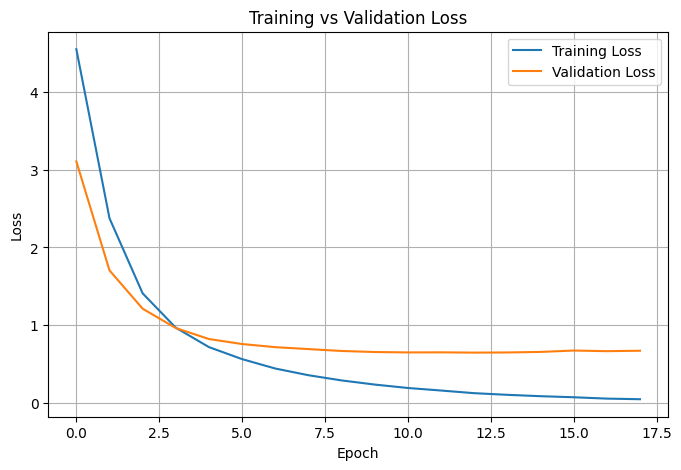

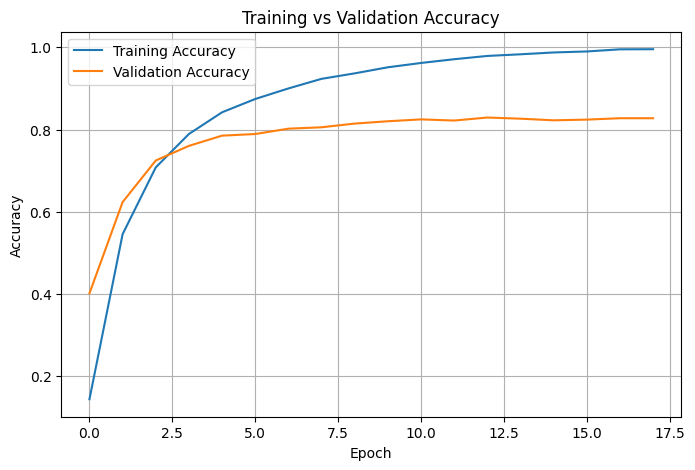

In [75]:
#--- Plot training and validation loss vs. epoch ---

plt.figure(figsize=(8, 5))

plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")

plt.legend()
plt.grid(True)

plt.show()

# --- Plot training and validation accuracy vs. epoch ---

plt.figure(figsize=(8, 5))

plt.plot(train_accuracies, label="Training Accuracy")
plt.plot(val_accuracies, label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")

plt.legend()
plt.grid(True)

plt.show()

The following code loads the finetuned ResNet50 feature extractor using the learned weights from the file *ResNet50_CUB_weights.pth*.

In [ ]:
# Recreate model architecture
ResNet50 = models.resnet50(weights=None)

# Recreate classifier layer
ResNet50.fc = nn.Linear(
    ResNet50.fc.in_features,
    200)

# Load saved weights
ResNet50.load_state_dict(
    torch.load("ResNet50_CUB_weights.pth"))



The below code evaluates the finetuned ResNet50 on the testing set.

In [76]:
# --- TEST SET EVALUATION ---

# Set model to evaluation mode
ResNet50.eval()

# Track Top-1 and Top-5 accuracy
correct_top1 = 0
correct_top5 = 0
total = 0

# Store predictions and true labels
preds_ResNet50 = []
true_ResNet50 = []

# Store Top-5 predictions
top5_ResNet50 = []

# Disable gradient computation
with torch.no_grad():

    for inputs, labels in test_loader:

        # Move batch to GPU/CPU
        inputs = inputs.to(device)
        labels = labels.to(device)

        # Forward pass
        outputs = ResNet50(inputs)

        # Top-1 predictions
        _, preds = torch.max(outputs, 1)

        # Top-5 predictions
        _, top5_preds = torch.topk(outputs, 5, dim=1)

        # Store predictions and labels
        preds_ResNet50.extend(preds.cpu().numpy())
        true_ResNet50.extend(labels.cpu().numpy())

        # Store Top-5 predictions
        top5_ResNet50.extend(top5_preds.cpu().numpy())

        # Update Top-1 accuracy
        correct_top1 += (preds == labels).sum().item()

        # Update Top-5 accuracy
        correct_top5 += (
            top5_preds == labels.view(-1, 1)
        ).sum().item()

        # Update total samples
        total += labels.size(0)

# Final accuracies
top1_acc_ResNet50 = correct_top1 / total
top5_acc_ResNet50 = correct_top5 / total

print(f"Top-1 Accuracy = {top1_acc_ResNet50:.4f}")
print(f"Top-5 Accuracy = {top5_acc_ResNet50:.4f}")

KeyboardInterrupt: 

## Comparison of results

Basic metrics:

In [ ]:
from sklearn.metrics import (
    classification_report,
    accuracy_score,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)

# ----- Function for Top5 accuracy -----
def top5_accuracy(true_labels, top5_predictions):
    correct = 0
    for true, top5 in zip(true_labels, top5_predictions):
        if true in top5:
            correct += 1
    return correct / len(true_labels)


# ---------------------------------------------------------------
# Fine-tuned ResNet50
# ---------------------------------------------------------------
print("========== ResNet50 ==========")

print(f"Top-1 Accuracy : {accuracy_score(true_ResNet50, preds_ResNet50):.4f}")
print(f"Top-5 Accuracy : {top5_accuracy(true_ResNet50, top5_ResNet50):.4f}")
print(f"Precision      : {precision_score(true_ResNet50, preds_ResNet50, average='weighted'):.4f}")
print(f"Recall         : {recall_score(true_ResNet50, preds_ResNet50, average='weighted'):.4f}")
print(f"F1 Score       : {f1_score(true_ResNet50, preds_ResNet50, average='weighted'):.4f}")

print("\nClassification Report:")
print(classification_report(true_ResNet50, preds_ResNet50)) 

# ---------------------------------------------------------------
# Vision Transformer
# ---------------------------------------------------------------
print("\n========== ViT ==========")

print(f"Top-1 Accuracy : {accuracy_score(true_ViT, preds_ViT):.4f}")
print(f"Top-5 Accuracy : {top5_accuracy(true_ViT, top5_ViT):.4f}")
print(f"Precision      : {precision_score(true_ViT, preds_ViT, average='weighted'):.4f}")
print(f"Recall         : {recall_score(true_ViT, preds_ViT, average='weighted'):.4f}")
print(f"F1 Score       : {f1_score(true_ViT, preds_ViT, average='weighted'):.4f}")

print("\nClassification Report:")
print(classification_report(true_ViT, preds_ViT))

# ---------------------------------------------------------------
# HVCNet
# ---------------------------------------------------------------
print("\n========== HVCNet ==========")

print(f"Top-1 Accuracy : {accuracy_score(true_HVC, preds_HVC):.4f}")
print(f"Top-5 Accuracy : {top5_accuracy(true_HVC, top5_HVC):.4f}")
print(f"Precision      : {precision_score(true_HVC, preds_HVC, average='weighted'):.4f}")
print(f"Recall         : {recall_score(true_HVC, preds_HVC, average='weighted'):.4f}")
print(f"F1 Score       : {f1_score(true_HVC, preds_HVC, average='weighted'):.4f}")

print("\nClassification Report:")
print(classification_report(true_HVC, preds_HVC))

========== ResNet50 ==========


NameError: name 'true_ResNet50' is not defined

In [78]:
# Load pretrained ResNet50 model with ImageNet weights
ResNet50 = models.resnet50(weights=None) # default weights are version 2

# Replace final classification layer for 200 classes (CUB)
ResNet50.fc = nn.Linear(ResNet50.fc.in_features, 200)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

#### Move model to GPU/CPU
ResNet50.to(device)


# Encode string class labels as integers (required for model)
label_encoder = LabelEncoder()
df["Label"] = label_encoder.fit_transform(df["Class"])


In [76]:
train_loader_cnn = DataLoader(
    train_dataset_vit,
    batch_size=32,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

val_loader_cnn = DataLoader(
    val_dataset_vit,
    batch_size=32,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

test_loader_cnn = DataLoader(
    test_dataset_vit,
    batch_size=32,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)


In [79]:
from torch.cuda.amp import GradScaler, autocast
scaler = torch.amp.GradScaler('cuda')
# Cross entropy loss function
criterion = nn.CrossEntropyLoss()

# Adam optimizer (adaptive learning rate for trainable parameters)
optimizer = optim.AdamW(ResNet50.parameters(), lr=1e-3, weight_decay=1e-3)

# Adaptive learning rate (reduces if no improvement in validation loss for 2 epochs)
scheduler = ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=2
)

# Maximum number of training epochs
num_epochs = 20

# Early stopping criteria
patience = 5

# Track best validation loss
best_val_loss = float("inf")

# Track epochs without improvement in validation loss
epochs_no_improve = 0

# Initialise to save best model weights
best_model_weights = copy.deepcopy(ResNet50.state_dict())

# Store metrics across epochs
train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []

# Time at start of finetuning
start_finetune = time.time()

# --- MODEL TRAINING ---
for epoch in range(num_epochs):

    # Time at start of current epoch
    start_epoch = time.time()
    
    # --- Training ---
    ResNet50.train() # set model to training model

    # Initialise training loss and accuracy
    train_loss = 0.0
    train_correct = 0

    for inputs, labels in tqdm(train_loader_cnn, desc=f"Epoch {epoch+1}/{num_epochs}"):
    
        inputs = inputs.to(device)
        labels = labels.long().to(device)
        
        optimizer.zero_grad()
        with autocast():
            outputs = ResNet50(inputs)
            loss = criterion(outputs, labels)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        train_loss += loss.item() * inputs.size(0)     
        train_correct += (outputs.argmax(dim=1) == labels).sum().item()

    # Compute average training loss
    train_loss /= len(train_dataset)
    # Compute training accuracy
    train_acc = train_correct  / len(train_dataset)
    
    # --- Validation ---
    ResNet50.eval() # set model to evaluation mode

    # Initialise validation loss and accuracy
    val_loss = 0.0
    val_correct = 0

    # Turn off gradient computation
    with torch.no_grad():

        for inputs, labels in tqdm(val_loader_cnn, desc="Validation", leave=False):

            inputs = inputs.to(device)
            labels = labels.long().to(device)
        
            with autocast():                        # ← add this
                outputs = ResNet50(inputs)
                loss = criterion(outputs, labels)
            val_loss += loss.item() * inputs.size(0)       
            val_correct += (outputs.argmax(dim=1) == labels).sum().item()

    # Compute average validation loss
    val_loss /= len(val_dataset)

    # Update learning rate scheduler
    scheduler.step(val_loss)

    # Compute validation accuracy
    val_acc = val_correct  / len(val_dataset)

    # -- Store training and validation losses per epoch ---
    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    # End epoch timer
    end_epoch = time.time()

    # Compute runtime for the given epoch
    time_epoch = end_epoch - start_epoch

    # Get current learning rates
    lrs = [group["lr"] for group in optimizer.param_groups]
 
    
    # Print epoch results
    print(
        f"Epoch {epoch+1}: "
        f"time = {time_epoch:.2f}, "
        f"lrs = {lrs}, "
        f"train loss = {train_loss:.4f}, "
        f"train acc = {train_acc:.4f}, "
        f"val loss = {val_loss:.4f}, "
        f"val acc = {val_acc:.4f}"
    )

    # --- Early stopping ---
    # If there is improvement in validation loss
    if val_loss < best_val_loss: 

        # Update best validation score
        best_val_loss = val_loss
        
        # Update best model parameter weights
        best_model_weights = copy.deepcopy(
            ResNet50.state_dict()
        )

        # Reset number of epochs with no improvement in validation loss
        epochs_no_improve = 0

    # If there is no improvement in validation loss
    else:

        # Increment epochs with no improvement counter
        epochs_no_improve += 1
        print(f"No improvement for {epochs_no_improve} epoch(s)")

    # If the consecutive number of epochs with no improvements reaches early stopping criteria
    if epochs_no_improve >= patience:
        print("Early stopping triggered")

        # End training
        break

# End finetuning timer
end_finetune = time.time()

# Compute total time taken to finetune
time_finetune = end_finetune - start_finetune
print(f"Total time taken to finetune ResNet50 = {time_finetune:.2f}")


# Restore best model (best performance on validation)
ResNet50.load_state_dict(best_model_weights) 

# Save learned model weights 
torch.save(
    ResNet50.state_dict(),
    "ResNet50_CUB_Noweights.pth"
)

print("done")

Epoch 1/20:   0%|                                                                              | 0/258 [00:00<?, ?it/s]C:\Users\Jack\AppData\Local\Temp\ipykernel_27220\741826330.py:61: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Validation:   0%|                                                                               | 0/56 [00:00<?, ?it/s]C:\Users\Jack\AppData\Local\Temp\ipykernel_27220\741826330.py:91: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():                        # ← add this
                                                                                                                       

Epoch 1: time = 265.31, lrs = [0.001], train loss = 5.3803, train acc = 0.0098, val loss = 5.0715, val acc = 0.0164


Epoch 2/20: 100%|████████████████████████████████████████████████████████████████████| 258/258 [04:04<00:00,  1.05it/s]
                                                                                                                       

Epoch 2: time = 264.51, lrs = [0.001], train loss = 5.0657, train acc = 0.0165, val loss = 5.0671, val acc = 0.0243


Epoch 3/20: 100%|████████████████████████████████████████████████████████████████████| 258/258 [04:04<00:00,  1.06it/s]
                                                                                                                       

...

Epoch 18: time = 258.33, lrs = [0.001], train loss = 1.9922, train acc = 0.4670, val loss = 2.4024, val acc = 0.4061
No improvement for 1 epoch(s)


Epoch 19/20: 100%|███████████████████████████████████████████████████████████████████| 258/258 [03:58<00:00,  1.08it/s]
                                                                                                                       

Epoch 19: time = 258.25, lrs = [0.001], train loss = 1.8599, train acc = 0.5038, val loss = 2.3259, val acc = 0.4316


Epoch 20/20: 100%|███████████████████████████████████████████████████████████████████| 258/258 [03:58<00:00,  1.08it/s]
                                                                                                                       

Epoch 20: time = 258.06, lrs = [0.001], train loss = 1.7556, train acc = 0.5197, val loss = 2.2081, val acc = 0.4564
Total time taken to finetune ResNet50 = 5228.00
done


In [80]:
# --- TEST SET EVALUATION ---

# Set model to evaluation mode
ResNet50.eval()

# Track Top-1 and Top-5 accuracy
correct_top1 = 0
correct_top5 = 0
total = 0

# Store predictions and true labels
preds_ResNet50 = []
true_ResNet50 = []

# Store Top-5 predictions
top5_ResNet50 = []

# Disable gradient computation
with torch.no_grad():

    for inputs, labels in test_loader:

        # Move batch to GPU/CPU
        inputs = inputs.to(device)
        labels = labels.to(device)

        # Forward pass
        outputs = ResNet50(inputs)

        # Top-1 predictions
        _, preds = torch.max(outputs, 1)

        # Top-5 predictions
        _, top5_preds = torch.topk(outputs, 5, dim=1)

        # Store predictions and labels
        preds_ResNet50.extend(preds.cpu().numpy())
        true_ResNet50.extend(labels.cpu().numpy())

        # Store Top-5 predictions
        top5_ResNet50.extend(top5_preds.cpu().numpy())

        # Update Top-1 accuracy
        correct_top1 += (preds == labels).sum().item()

        # Update Top-5 accuracy
        correct_top5 += (
            top5_preds == labels.view(-1, 1)
        ).sum().item()

        # Update total samples
        total += labels.size(0)

# Final accuracies
top1_acc_ResNet50 = correct_top1 / total
top5_acc_ResNet50 = correct_top5 / total

print(f"Top-1 Accuracy = {top1_acc_ResNet50:.4f}")
print(f"Top-5 Accuracy = {top5_acc_ResNet50:.4f}")

Top-1 Accuracy = 0.4381
Top-5 Accuracy = 0.7332


In [81]:
print("========== ResNet50 ==========")

print(f"Top-1 Accuracy : {accuracy_score(true_ResNet50, preds_ResNet50):.4f}")
print(f"Top-5 Accuracy : {top5_accuracy(true_ResNet50, top5_ResNet50):.4f}")
print(f"Precision      : {precision_score(true_ResNet50, preds_ResNet50, average='weighted'):.4f}")
print(f"Recall         : {recall_score(true_ResNet50, preds_ResNet50, average='weighted'):.4f}")
print(f"F1 Score       : {f1_score(true_ResNet50, preds_ResNet50, average='weighted'):.4f}")

print("\nClassification Report:")
print(classification_report(true_ResNet50, preds_ResNet50)) 

========== ResNet50 ==========
Top-1 Accuracy : 0.4381
Top-5 Accuracy : 0.7332
Precision      : 0.4927
Recall         : 0.4381
F1 Score       : 0.4180

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.11      0.20         9
           1       0.67      0.44      0.53         9
           2       0.00      0.00      0.00         9
           3       0.11      0.67      0.18         9
           4       0.60      0.50      0.55         6
           5       0.30      0.50      0.38         6
           6       0.50      0.62      0.56         8
           7       0.26      0.86      0.40         7
           8       0.20      0.11      0.14         9
           9       0.88      0.78      0.82         9
          10       0.33      0.11      0.17         9
          11       1.00      0.75      0.86         8
          12       0.67      0.67      0.67         9
          13       0.62      0.56      0.59         9
          14  

C:\Users\Jack\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Jack\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Jack\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classif